# Post mofa-flex analysis

### Contents:

1. [Load models (Normal, SnS, and GP).](#load-models)

2. [MOFA-Flex model result overview.](#mofa-flex-results-overview)
<br>
2.1 [Factor correlation and variance explained.](#1-variance-explained)
<br>
2.2 [Average R2.](#2-average-r2)
<br>
2.3 [Weights distribution.](#3weights-dist)
<br>
2.4 [Heatmap (view x LR).](#4-heatmap-view-x-lr)

3. [DR and clustering.](#dr-using-factors-values)

4. [Regression Model.](#regression-model)
<br>
4.1 [Evaluate model.](#evaluate-the-model)
<br>
4.2 [AUC.](#auc)

In [ ]:
import os.path
import anndata as ad
import mudata as md
import numpy as np
import pandas as pd
import mofaflex as mfl
from plotnine import *
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from umap import UMAP
from sklearn.manifold import TSNE

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



# Load models

### Normal

In [5]:
models_path = Path("/g/stegle/aalsayah/repos/data/models_obj")

In [117]:
model= mfl.MOFAFLEX.load(models_path / 'crc_110.hdf5')

WARNING	The stored model was created with a different version of MOFA-FLEX. Some features may not work.


### SnS

In [159]:
model = mfl.MOFAFLEX.load(models_path / "sns_models/crc_110/Normal.SnS/crc_110.Normal.SnS.hdf5")

WARNING	The stored model was created with a different version of MOFA-FLEX. Some features may not work.


### GP

In [ ]:
#model = mfl.MOFAFLEX.load(models_path / "GP_models/crc_232_no_mye_IgM/GP.Normal/crc_232_no_mye_IgM.GP.Normal.hdf5")

# MOFA-Flex results overview

## 1. Variance Explained

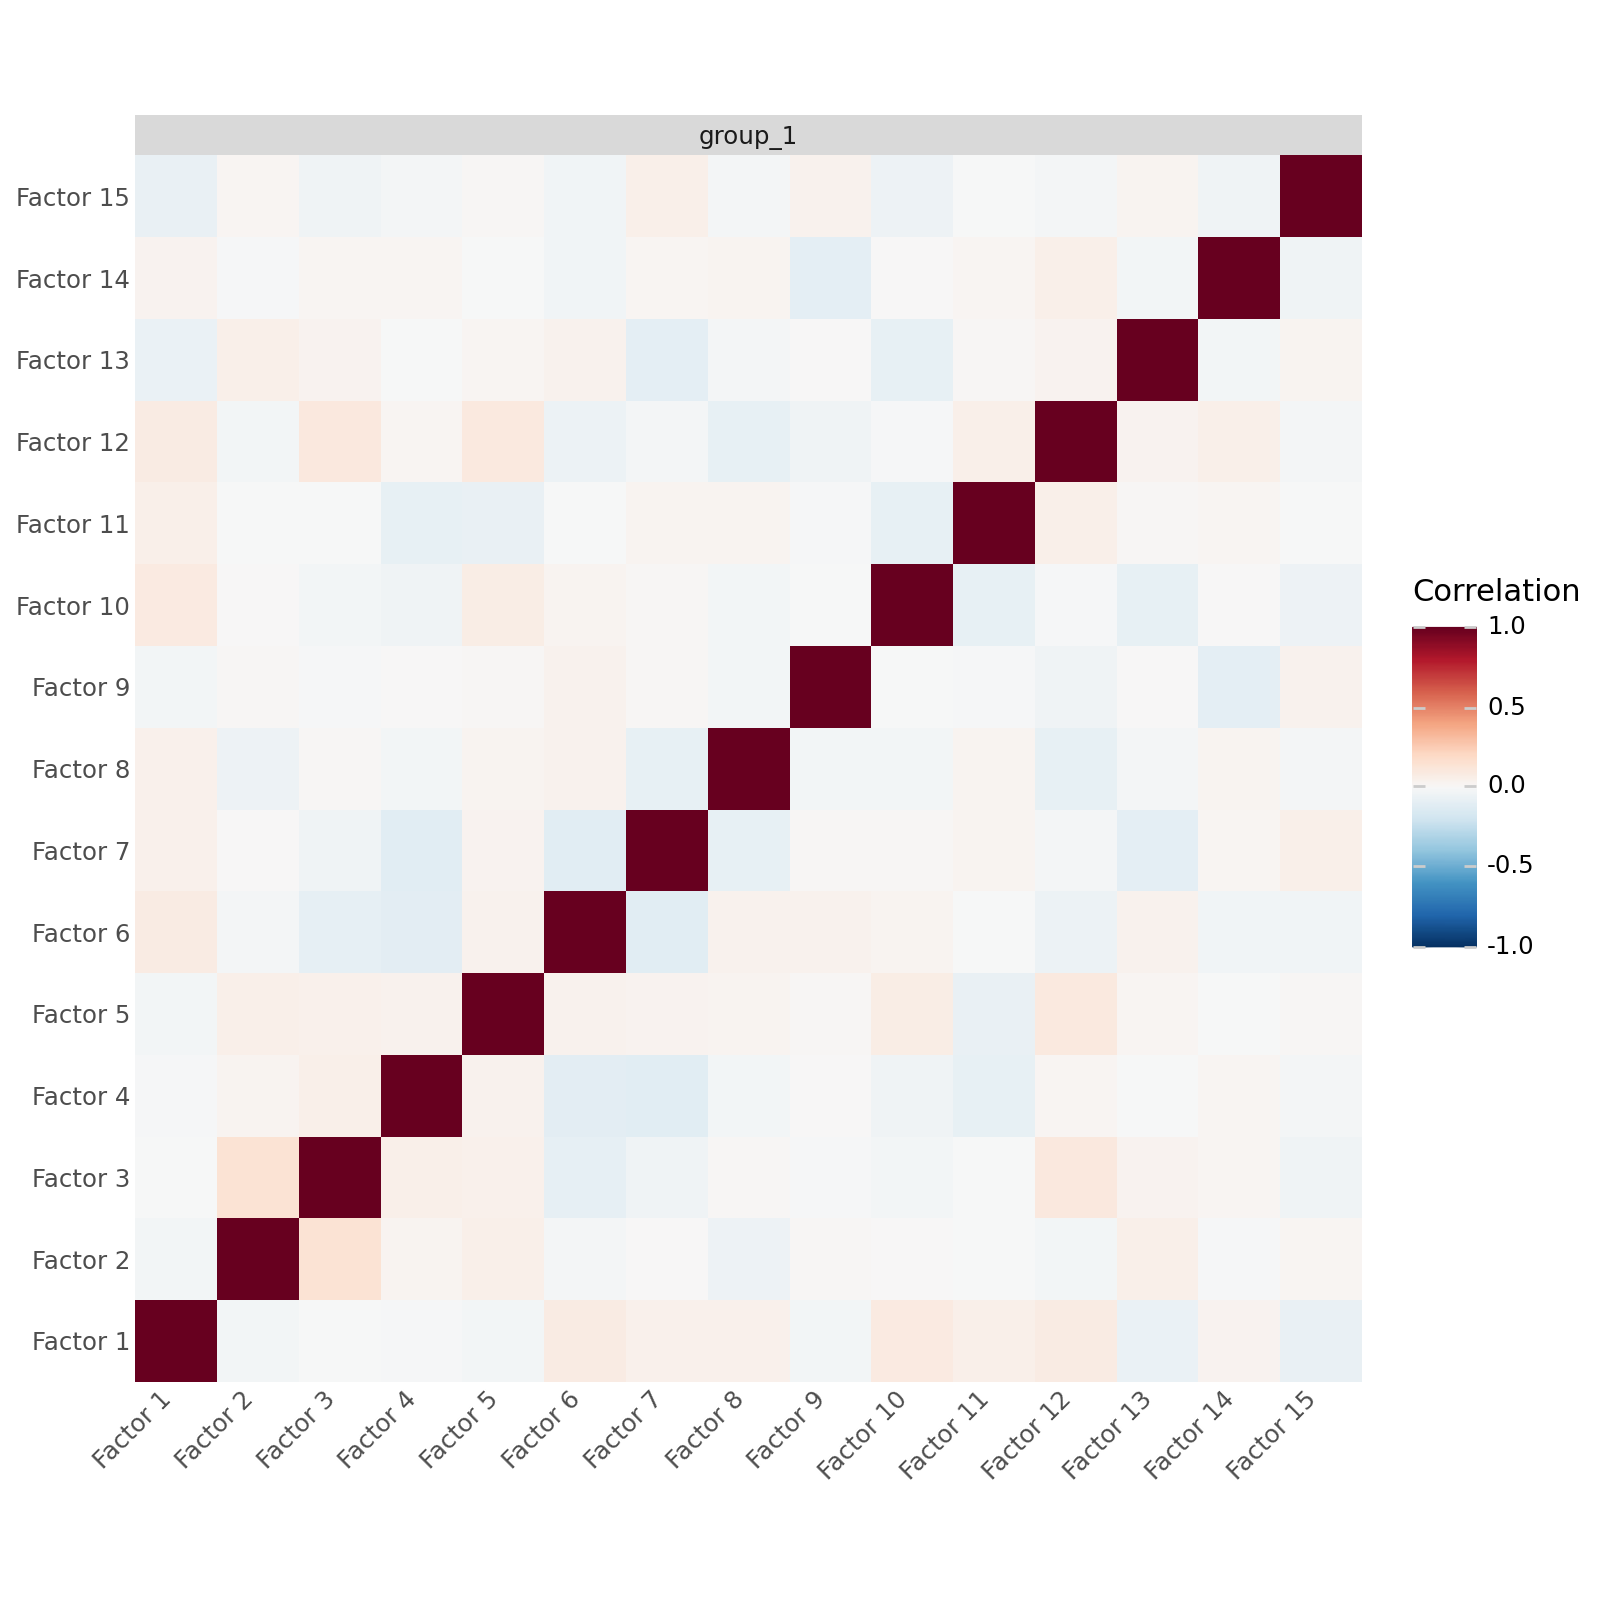

In [160]:
mfl.pl.factor_correlation(model)

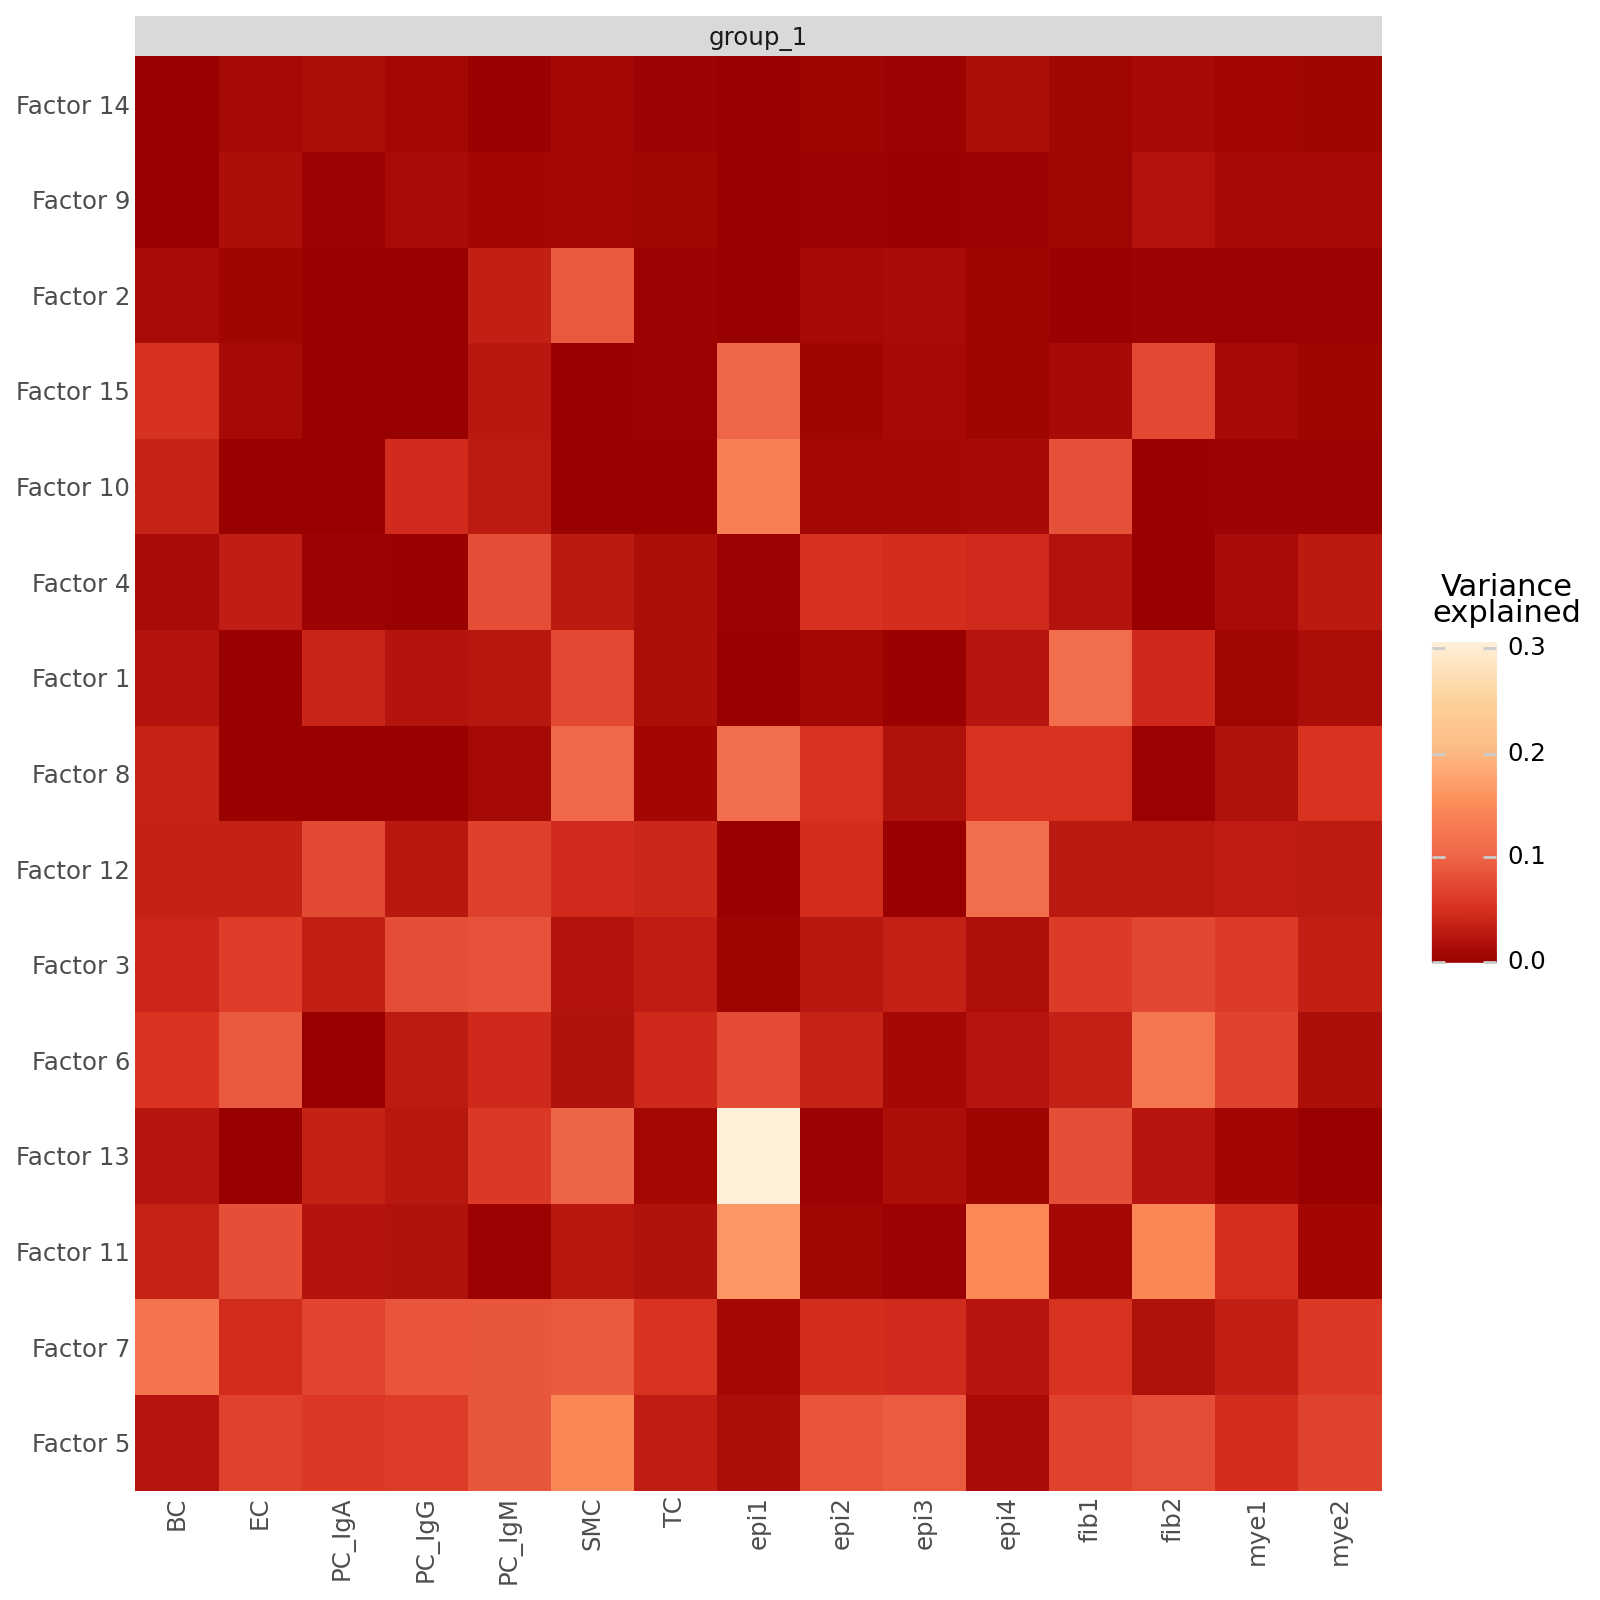

In [161]:
mfl.pl.variance_explained(model, figsize= (8,8))

## 2. Average R2

In [162]:
print(model.get_r2(total=True))

         group_1
epi4    0.487054
epi1    0.917116
epi3    0.412363
epi2    0.399775
fib2    0.733150
mye1    0.374512
mye2    0.432698
BC      0.547804
EC      0.484719
TC      0.322192
PC_IgG  0.505881
PC_IgA  0.515899
PC_IgM  0.574524
fib1    0.609506
SMC     0.809576


In [163]:
r2 = model.get_r2(total=True)
r2["group_1"].mean()

0.5417846739568287

## 3.Weights dist

In [164]:
weights_dict= model.get_weights()

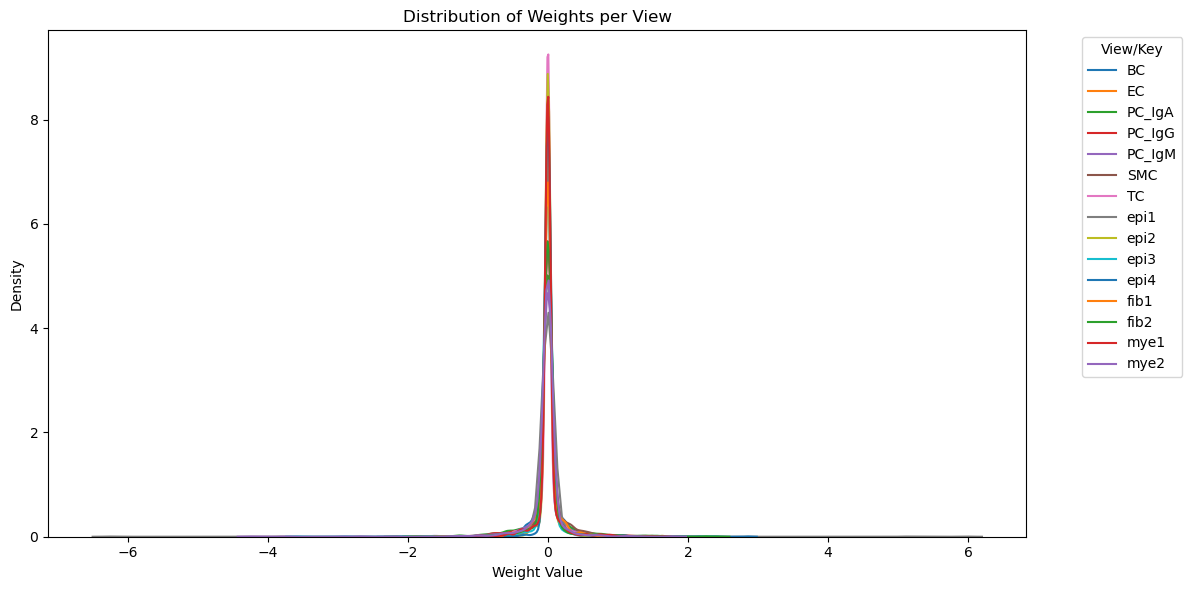

In [165]:
plt.figure(figsize=(12, 6))

# Loop through each view/key
for key, df in weights_dict.items():
    # Flatten all weights from that DataFrame into 1D array
    values = df.values.flatten()
    sns.kdeplot(values, label=key, fill=False)  # distribution curve

plt.title("Distribution of Weights per View")
plt.xlabel("Weight Value")
plt.ylabel("Density")
plt.legend(title="View/Key", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [124]:
#mfl.pl.all_weights(model_gp, views=['fib2'], figsize=(8,8), show_featurenames=True)
#mfl.pl.weights(model, n_features=10, views=["fib2"], factors=1, pointsize=2, figsize=(8,8))
#mfl.pl.top_weights(model, n_features=15, views="fib2", factors=1)

## 4. Heatmap (view x LR)

In [166]:
from string import ascii_uppercase
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

In [167]:
weights = model.get_weights()

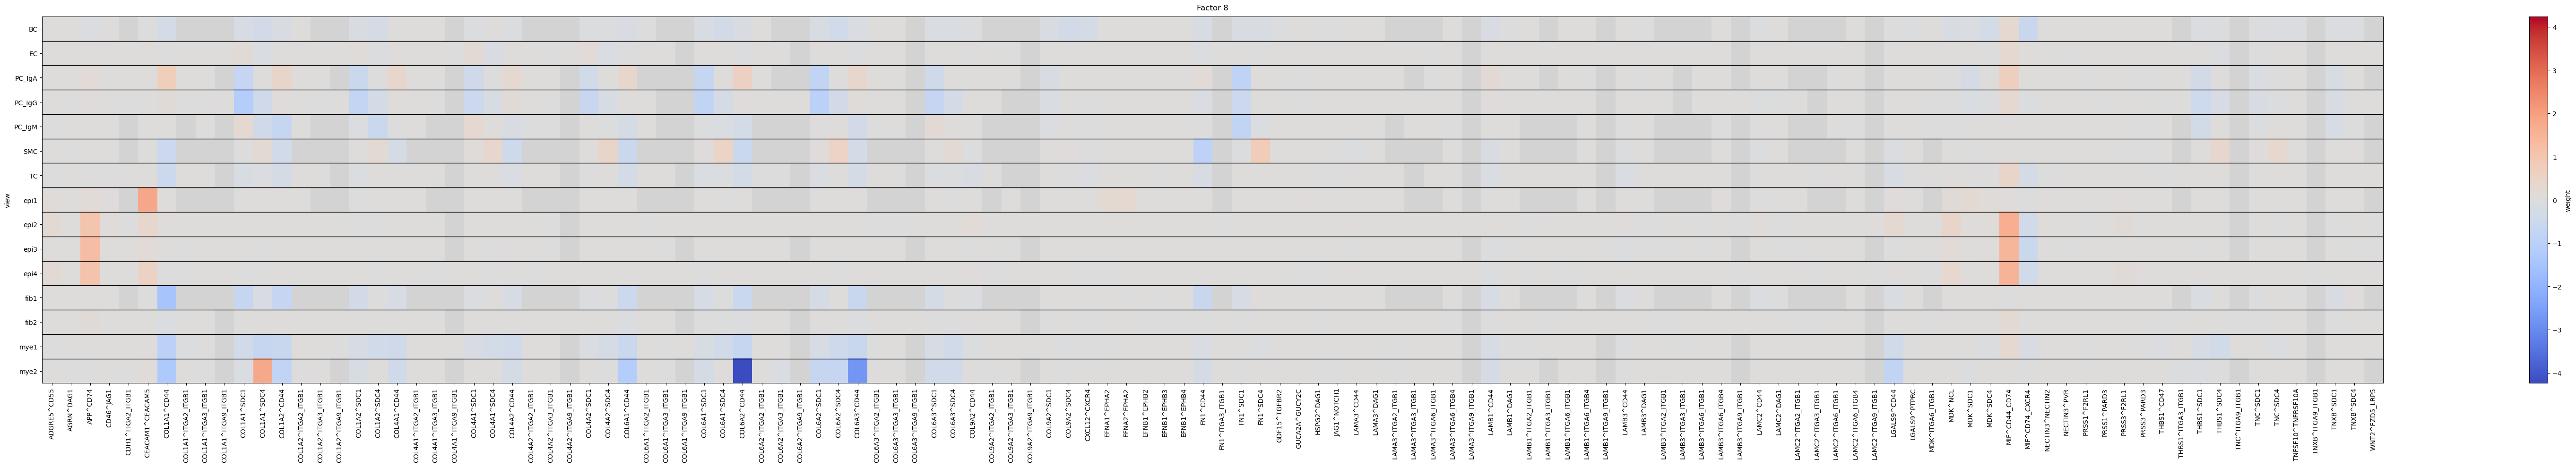

In [168]:
import re
from matplotlib.colors import TwoSlopeNorm

# choose the factor you want:
factor = 8 

def resolve_factor_label(df, factor):
    """
    Return the exact row label in df.index for a given factor selector.
    Accepts: 3, "3", "Factor 3", "factor 03", etc.
    """
    idx_map = {str(idx).strip().lower(): idx for idx in df.index}
    key = str(factor).strip().lower()
    # exact match first
    if key in idx_map:
        return idx_map[key]
    # otherwise pull the first integer and try "Factor {n}"
    m = re.search(r'\d+', key)
    if m:
        candidate = f"factor {int(m.group())}"
        if candidate in idx_map:
            return idx_map[candidate]
    raise KeyError(f"Couldn't find factor '{factor}'. Available: {list(df.index)}")

rows, labels = [], []
for view, df in weights.items():
    row_label = resolve_factor_label(df, factor)
    s = df.loc[row_label].copy()
    s.index = ['^'.join(c.split('^')[1:]) for c in s.index]  # drop prefix before first ^
    rows.append(s)
    labels.append(view)

# assemble matrix (align columns across views)
all_cols = sorted({c for s in rows for c in s.index})
X = pd.DataFrame([s.reindex(all_cols) for s in rows], index=labels)

plt.figure(figsize=(0.5*X.shape[1] + 2, 0.6*X.shape[0] + 1))

# zero-centered diverging colormap
v = np.nanmax(np.abs(X.values))
norm = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)
cmap = plt.get_cmap('coolwarm').copy()
cmap.set_bad('lightgray')  # NaNs

im = plt.imshow(np.ma.masked_invalid(X.values),
                aspect='auto', interpolation='nearest',
                cmap=cmap, norm=norm)

plt.yticks(range(X.shape[0]), X.index)
plt.xticks(range(X.shape[1]), X.columns, rotation=90)
plt.ylabel("view")
plt.colorbar(im, label="weight")
for r in range(1, X.shape[0]):
    plt.axhline(r - 0.5, color='black', lw=1)
plt.title(f"Factor {factor}", pad=10)  # shows "Factor 3" if you passed 3
plt.tight_layout()
plt.show()


# DR using factors values

In [169]:
factors = model.get_factors()
factors = factors["group_1"]

In [170]:
factors

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
c_1_1_1,-0.986488,3.573435,0.471832,-0.616423,1.715483,-1.040181,-0.530924,-0.820428,0.233744,-1.508960,2.935467,0.416530,-2.556357,-0.246029,-1.455982
c_1_1_2,-1.800150,2.483528,5.599481,-0.927170,-3.144641,-0.228878,0.394214,-1.197850,0.422724,-0.791851,-0.535454,3.845761,-10.802848,-0.547347,0.201120
c_1_1_10,-0.027976,2.514936,0.208837,-0.045399,0.308171,-1.258609,-0.097989,0.156796,0.218482,0.121627,0.024868,0.604255,-8.100985,-0.223188,-0.249327
c_1_1_11,0.230528,-0.842302,2.231647,1.025774,0.156179,-0.961999,-0.081612,-0.757613,0.087110,0.121222,-0.443708,0.069370,-0.691993,-0.062359,-1.488182
c_1_1_16,2.228712,-0.023155,-0.492392,-0.700221,-0.986225,3.625440,-0.389552,0.064338,0.143490,-0.932063,0.825572,-1.207865,-0.297071,-0.103143,-0.415505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_1_334_669,-2.936657,0.500610,-0.572840,2.998086,-0.477922,-0.678178,2.385794,-0.143001,-3.108180,2.067678,1.142562,2.069858,-0.636655,0.888821,-1.582110
c_1_334_696,1.320602,0.057399,-2.994262,-1.938592,1.303829,-0.623663,-1.272826,-0.992330,1.008663,-2.017618,-1.152718,-1.424533,-1.162992,-1.729034,-1.104107
c_1_334_697,2.670573,-0.373268,-5.903500,-4.114469,3.128972,-0.884667,-2.782051,-2.193917,2.354505,-3.815049,-2.135297,-2.761120,-2.680218,-3.663559,-1.524642
c_1_371_154,-1.480191,-0.740358,1.779258,-2.294492,0.073580,0.619842,1.949808,0.143445,1.505694,-0.463787,0.591405,-0.290745,0.112560,-0.141506,-6.005795


### Load lrdata

In [131]:
data_path = Path("/g/stegle/aalsayah/repos/data/lrdata_processed")
lrdata = sc.read_h5ad(data_path/ "crc_110_lrdata.h5ad")

In [171]:
lv1 = lrdata.obs["lv1"]
lv2 = lrdata.obs["lv2"]
ist = lrdata.obs["ist"]
typ = lrdata.obs["typ"]

In [172]:
lv1 = lv1.loc[lv1.index.intersection(factors.index)]
lv1 = lv1.reindex(factors.index)
lv1.shape

(264707,)

### UMAP

In [173]:
import umap.umap_ as umap
from sklearn.preprocessing import StandardScaler
import hdbscan

In [174]:
# --- Standardize ---
scaler = StandardScaler()
X = scaler.fit_transform(factors)

In [175]:
# --- UMAP for clustering (higher-D) ---
umap_clusters = umap.UMAP(
    n_components=10,
    n_neighbors=50,          # try 15, 30, 50
    min_dist=0.2,           # try 0.0–0.2
    metric="euclidean",      # try 'cosine' or 'correlation'
    random_state=42
).fit_transform(X)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


In [ ]:
# --- HDBSCAN: start conservative ---
n = X.shape[0]
mcs = max(30, int(np.sqrt(n)))    # rule-of-thumb: sqrt(n) or ~1–5% of n

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=mcs,
    min_samples=None,               # or set = mcs for even fewer/simpler clusters
    cluster_selection_method="eom",  # <- less split-happy than 'leaf'
    cluster_selection_epsilon=0.05   # <- gently merges adjacent leaves; try 0.02–0.15
).fit(umap_clusters)

labels = clusterer.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_rate = (labels == -1).mean()
print(f"clusters={n_clusters}, noise={noise_rate:.2%}")

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.


clusters=11, noise=2.43%


---

#### Old cluster - ignore?

In [42]:
# --- HDBSCAN (tunable) ---
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5,         # sweep 5, 10, 20, 50
    min_samples=None,            # or small ints: 5–10
    cluster_selection_method="leaf"
)
labels = clusterer.fit_predict(umap15)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.


In [43]:
len(np.unique(labels))

524

----

#### 2D UMAP

In [ ]:
# --- 2D UMAP for visualization only ---
umap2 = umap.UMAP(
    n_components=2,
    n_neighbors=50,
    min_dist=0.2,
    metric="euclidean",
    random_state=42
).fit_transform(X)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


In [139]:
df_umap = pd.DataFrame(umap2, columns=['UMAP1','UMAP2'], index=factors.index)
df_umap['Cluster'] = labels
df_umap['Conf'] = clusterer.probabilities_  # how confident each assignment is

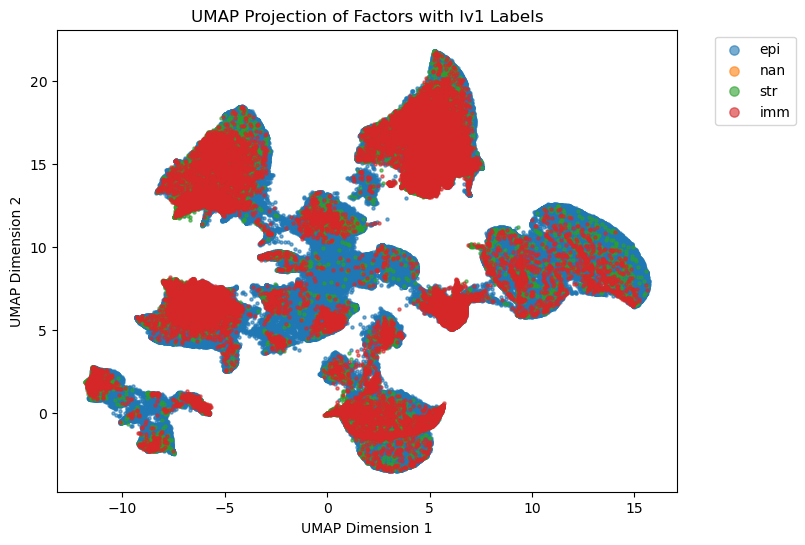

In [140]:
df_umap['Label'] = lv1.loc[factors.index].values

# Step 4: Plot UMAP with labels
plt.figure(figsize=(8,6))
for label in df_umap['Label'].unique():
    subset = df_umap[df_umap['Label'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of Factors with lv1 Labels")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

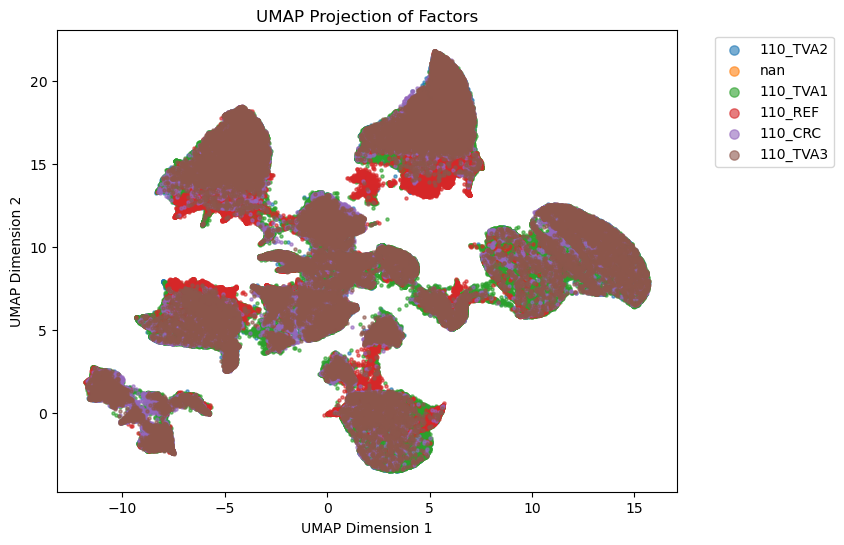

In [141]:
df_umap['Label'] = typ.loc[factors.index].values

# Step 4: Plot UMAP with labels
plt.figure(figsize=(8,6))
for label in df_umap['Label'].unique():
    subset = df_umap[df_umap['Label'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of Factors")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

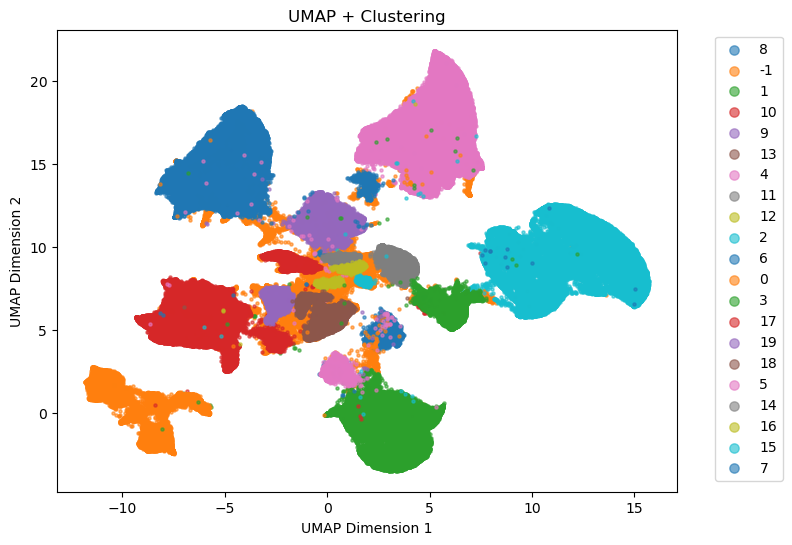

In [143]:
#Plot clusters

plt.figure(figsize=(8,6))
for label in df_umap['Cluster'].unique():
    subset = df_umap[df_umap['Cluster'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP + Clustering")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Regression Model

In [144]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [145]:
#get variables 
factors = model.get_factors() 
F = factors["group_1"]

#Get dependent var, change typ to any metadata column you wish to predict if factor values can predict
cell_names = F.index
cell_types = lrdata.obs["lv1"]

#Sort both
cell_types = cell_types.sort_index()
F=  F.sort_index()

#Filter out any datapoint in response var that is not in features
filtered_cell_types = cell_types.loc[cell_types.index.isin(cell_names)]

### Create X and Y objects

In [146]:
F

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
c_1_100_1009,-1.476304,0.755532,-0.570409,1.533256,-0.811402,-0.360956,-0.074015,0.165007,-0.027867,1.819039,0.172837,1.062618,-0.074774,1.502203,1.577506
c_1_100_1039,0.096815,0.852674,0.811186,0.071918,-0.103162,-0.059919,-0.526279,-0.357264,0.111488,0.368758,-0.524703,-0.238566,-0.280419,0.181160,-0.340439
c_1_100_104,0.704660,-0.234421,-0.191723,0.316010,0.001611,-0.439980,0.227365,0.179033,0.064823,0.409413,-0.341207,0.056891,0.088672,-0.215196,-0.196704
c_1_100_105,-0.200457,-0.395995,-0.266103,0.165448,-0.063061,-0.558109,0.168904,-0.395348,-0.284949,0.049278,-0.286686,0.120712,-0.070006,0.366539,0.286023
c_1_100_1070,-0.006146,-0.081413,-0.047255,0.146108,-0.065339,-0.143779,0.214800,-0.078583,0.077644,-0.032127,-0.008666,-0.022405,0.175372,-0.101142,-0.104807
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_1_9_961,-0.334232,-0.478893,-0.242384,-0.155640,-0.706326,0.210380,-0.258592,-0.255412,0.123777,-0.062032,-0.022626,0.399855,0.384616,0.715077,0.127039
c_1_9_973,-0.302397,-0.061374,-0.201542,0.046444,-0.221564,0.267287,-0.074268,0.216430,0.221363,0.149433,0.095367,0.264577,0.122480,0.358561,0.087250
c_1_9_988,-0.012568,1.247050,-1.893353,-1.340191,-1.412615,-0.903036,-0.343429,0.360615,-0.500812,-1.280592,-1.612386,-1.052238,0.942644,-0.061561,1.385022
c_1_9_995,-1.410739,-0.463628,0.831014,-0.228666,0.574252,-0.543322,0.668551,-0.279387,0.161119,-0.555084,-0.260344,-1.137157,-0.186557,0.744347,0.462991


In [147]:
filtered_cell_types

c_1_100_1009    str
c_1_100_1039    epi
c_1_100_104     epi
c_1_100_105     epi
c_1_100_1070    epi
               ... 
c_1_9_961       epi
c_1_9_973       epi
c_1_9_988       epi
c_1_9_995       imm
c_1_9_999       imm
Name: lv1, Length: 264707, dtype: category
Categories (3, object): ['epi', 'imm', 'str']

In [148]:
X = F.values
y = filtered_cell_types.values  # labels

In [149]:
#Drop NaN labels
mask = ~pd.isna(y)
X = X[mask]
y = y[mask]

In [150]:
print(X.shape, y.shape)

(261350, 15) (261350,)


In [151]:
print("Min:", np.min(X))
print("Max:", np.max(X))
print("Mean:", np.mean(X))
print("Median:", np.median(X))
print("Std dev:", np.std(X))

Min: -11.578463
Max: 11.371277
Mean: 0.018370882
Median: 0.015155785
Std dev: 0.7952912


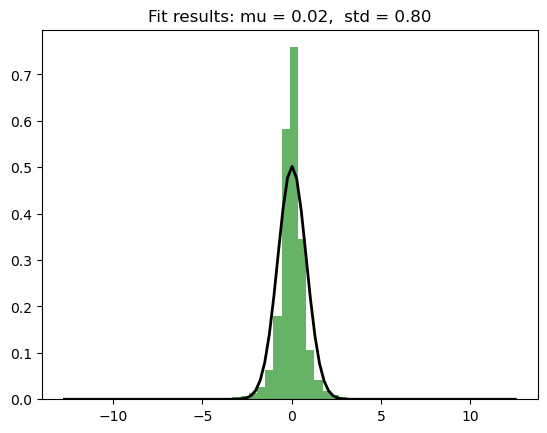

In [152]:
from scipy.stats import norm

data = X.flatten()

# histogram
plt.hist(data, bins=50, density=True, alpha=0.6, color='g')

# fit a normal
mu, std = norm.fit(data)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)

plt.title(f"Fit results: mu = {mu:.2f},  std = {std:.2f}")
plt.show()


### Train multinomial logistic regression

In [153]:
# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [154]:
clf = LogisticRegression(
    solver="lbfgs",
    max_iter=200,
    class_weight="balanced"
)

In [155]:
clf.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=200)

### Evaluate the model

In [156]:
# Evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6173075696703016

Classification Report:
               precision    recall  f1-score   support

         epi       0.93      0.65      0.76     67688
         imm       0.18      0.44      0.25      6341
         str       0.12      0.43      0.19      4376

    accuracy                           0.62     78405
   macro avg       0.41      0.50      0.40     78405
weighted avg       0.82      0.62      0.69     78405



### AUC

#### 1. If threr are 2 classes only:

In [157]:
from sklearn.metrics import roc_auc_score, roc_curve

AUC: 0.8091964143497761


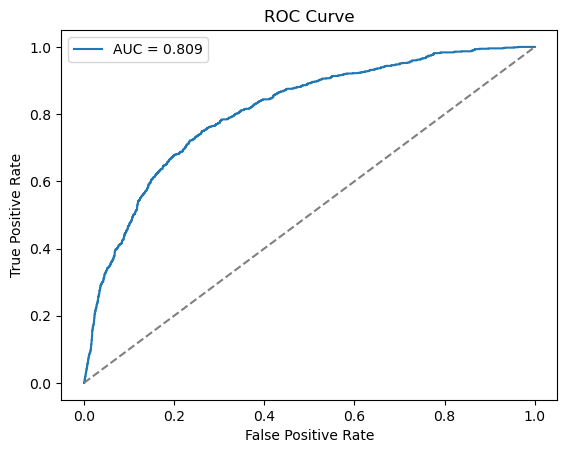

In [100]:
# Get predicted probabilities for the positive class (assume label "232_REF" is positive)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Calculate AUC
auc = roc_auc_score(y_test, y_pred_proba)
print("AUC:", auc)


fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label="232_REF")
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

#### 2. If classes are more than 2:

In [158]:
# Get class probabilities 
y_proba = clf.predict_proba(X_test)   # shape = (n_samples, 3)

# Compute macro-average AUC (each class equally weighted, good default)
auc_macro = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
print(f"Multiclass ROC AUC (OvR, macro): {auc_macro:.4f}")

# You could also try weighted averaging (weights by class support):
auc_weighted = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
print(f"Multiclass ROC AUC (OvR, weighted): {auc_weighted:.4f}")


Multiclass ROC AUC (OvR, macro): 0.7078
Multiclass ROC AUC (OvR, weighted): 0.7199
